<a href="https://colab.research.google.com/github/giuliabugatti09/bank_credit_card_churn_predicition/blob/main/notebooks/modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Credit Card Churn Prediction: Machine Learning Pipeline
> **Objective:** Develop a robust classifier to predict customer attrition and evaluate the financial impact of the model.

### 📈 Modeling Strategy:
1. **Custom Feature Engineering:** Create business-driven metrics.
2. **Preprocessing Pipeline:** Automate Scaling and Encoding.
3. **Model Selection:** Compare Linear vs. Tree-based models.
4. **Financial Validation:** Estimate the Profit generated by the model.

##Setup & Library Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

# ML Models & Utilities
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

##Custom Feature Engineering Class

In [9]:
class BankFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Financial behavior features
        X['total_spending'] = X['Total_Trans_Amt'] + X['Total_Revolving_Bal']
        X['credit_util_rate'] = X['Total_Revolving_Bal'] / (X['Credit_Limit'] + 1)
        X['inactivity_ratio'] = X['Months_Inactive_12_mon'] / (X['Months_on_book'] + 1)

        # Interaction features
        X['trans_ct_per_contacts'] = X['Total_Trans_Ct'] / (X['Contacts_Count_12_mon'] + 1)

        # Drop columns that are no longer needed or cause leakage
        cols_to_drop = ['CLIENTNUM', 'Attrition_Flag']
        X = X.drop(columns=[c for c in cols_to_drop if c in X.columns], errors='ignore')
        return X

##Data Loading & Split

In [10]:
df = pd.read_csv("/content/BankChurners.csv")

# Basic cleaning of leakage columns
leakage_cols = [c for c in df.columns if 'Naive_Bayes' in c]
df = df.drop(columns=leakage_cols)

# Target preparation
y = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})
X = df.drop(columns=['Attrition_Flag'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Building the Automated Pipeline

In [11]:
# Identify feature types
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
if 'CLIENTNUM' in num_cols: num_cols.remove('CLIENTNUM')
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Define Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Full Model Selection Pipeline
def build_model_pipeline(classifier):
    return Pipeline([
        ('feature_eng', BankFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

## Model Comparison (Linear vs Trees)

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results = []
for name, model in models.items():
    pipe = build_model_pipeline(model)
    # Cross-validation using F1-Score (Better for imbalanced Churn data)
    cv_results = cross_validate(pipe, X_train, y_train, cv=5, scoring='f1')
    results.append({
        'Model': name,
        'F1-Score Mean': cv_results['test_score'].mean(),
        'F1-Score Std': cv_results['test_score'].std()
    })

results_df = pd.DataFrame(results).sort_values(by='F1-Score Mean', ascending=False)
display(results_df)

,Model,F1-Score Mean,F1-Score Std
2,LightGBM,0.912016,0.009307
1,Random Forest,0.841118,0.007877
0,Logistic Regression,0.644117,0.010082


## Final Model Evaluation

=== FINAL MODEL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1701
           1       0.93      0.86      0.89       325

    accuracy                           0.97      2026
   macro avg       0.95      0.92      0.94      2026
weighted avg       0.97      0.97      0.97      2026

ROC-AUC Score: 0.9925


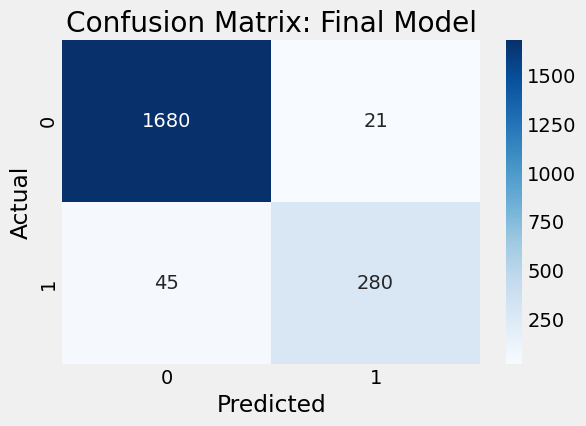

In [13]:
best_model_pipe = build_model_pipeline(LGBMClassifier(random_state=42, verbose=-1))
best_model_pipe.fit(X_train, y_train)

y_pred = best_model_pipe.predict(X_test)
y_proba = best_model_pipe.predict_proba(X_test)[:, 1]

print("=== FINAL MODEL CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Final Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##Feature Importance


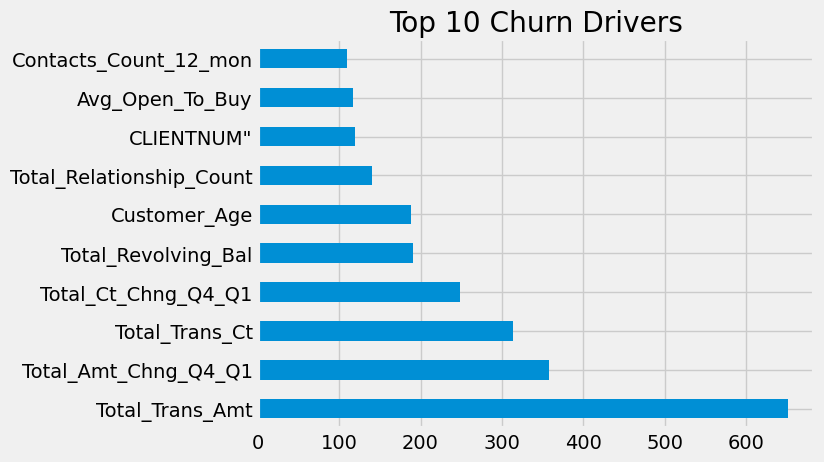

In [15]:
model = best_model_pipe.named_steps['classifier']
# Get feature names after one-hot encoding
cat_names = best_model_pipe.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out()
feature_names = num_cols + list(cat_names)

importances = pd.Series(model.feature_importances_, index=feature_names)
importances.nlargest(10).plot(kind='barh', title='Top 10 Churn Drivers')
plt.show()

##Financial Impact & Business Results

In [14]:
# Calculating the estimated profit based on the test set
# 18% rate on revolving balance
test_results = X_test.copy()
test_results['actual_churn'] = y_test.values
test_results['predicted_churn'] = y_pred

# Basic Profit Calculation logic (Simplification of your business rule)
revenue_tax = 0.18
retention_gain = 0.10
retention_cost = 0.08

def calculate_profit(row):
    # True Positive: Client identified and retained
    if row['actual_churn'] == 1 and row['predicted_churn'] == 1:
        return row['Total_Revolving_Bal'] * retention_gain
    # False Positive: Spent on retention for someone who wasn't leaving
    elif row['actual_churn'] == 0 and row['predicted_churn'] == 1:
        return - (row['Total_Revolving_Bal'] * retention_cost)
    # False Negative: Lost the whole client revenue
    elif row['actual_churn'] == 1 and row['predicted_churn'] == 0:
        return - (row['Total_Revolving_Bal'] * revenue_tax)
    else:
        return 0

total_profit = test_results.apply(calculate_profit, axis=1).sum()
print(f"💰 Estimated Model Economic Impact (Test Set): ${total_profit:,.2f}")

💰 Estimated Model Economic Impact (Test Set): $7,529.82
